In [ ]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import os

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay)

In [9]:
df = pd.read_csv("../Dataset/Heart.csv")

In [10]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (918, 11)
Target shape: (918,)


In [11]:
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = X.select_dtypes(
    include=["object"]
).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

Categorical columns:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


/var/folders/44/fywnm5sj335fdzvrq6s4_m3c0000gn/T/ipykernel_26363/3251459197.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


In [12]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42,stratify=y)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 734
Testing samples: 184


In [14]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [ ]:
params = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}
grid = GridSearchCV( pipeline, params, cv=5,scoring="accuracy")

In [ ]:
grid.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [17]:
print("Best parameters:", grid.best_params_)
print("Best cross-validation accuracy:", grid.best_score_)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Best parameters: {'classifier__C': 0.1}
Best cross-validation accuracy: 0.854151523623148
Training samples: 734
Testing samples: 184


In [ ]:
model = grid.best_estimator_
y_pred = model.predict(X_test)
print("Predictions generated successfully.")

Predictions generated successfully.


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8913043478260869


In [ ]:
print("Classification Report:")
print(classification_report(y_test,y_pred,target_names=[ "No Heart Disease","Heart Disease"]))

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.91      0.84      0.87        82
   Heart Disease       0.88      0.93      0.90       102

        accuracy                           0.89       184
       macro avg       0.89      0.89      0.89       184
    weighted avg       0.89      0.89      0.89       184



In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[69 13]
 [ 7 95]]


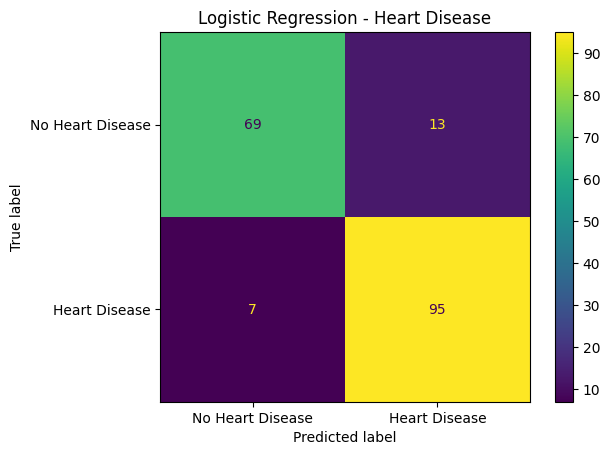

In [ ]:
display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["No Heart Disease","Heart Disease"])
display.plot()
plt.title("Logistic Regression - Heart Disease")
plt.show()